<a href="https://colab.research.google.com/github/zarin-t26/ASD-Model/blob/main/autismfinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**ETE 430: Neural and Fuzzy Systems in Communications Network**
# A Convolutional Neural Network Model for Early Stage Detection of Autism Spectrum Disorder (ASD)
Zarin Tasnim (1908015)

Dept. of Electronics and Telecommunication Engineering

## Mounting Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Dataset Selection and Environment Setup

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

## Library Installation and Imports for Model Development


In [ ]:
# Install necessary libraries
!pip install split_folders

# Import necessary libraries
import os
import shutil
import splitfolders
import tensorflow as tf
import seaborn as sns
import random
from tensorflow.keras.applications import VGG19, VGG16, Xception, MobileNetV2, InceptionV3, ResNet50
from tensorflow.keras import layers, mixed_precision
from tensorflow.keras.layers import Dense, Activation, Dropout, BatchNormalization, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image_dataset_from_directory
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve, roc_curve, auc
from sklearn.preprocessing import label_binarize
from mlxtend.plotting import plot_confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

## Dataset Loading

In [ ]:
mixed_precision.set_global_policy("float32")

# Load the dataset
loc = "/content/drive/MyDrive/AutismDataset/consolidated"

## Directory Setup and Data Splitting

In [ ]:
# Create output directories
os.makedirs('output', exist_ok=True)
os.makedirs('output/train', exist_ok=True)
os.makedirs('output/val', exist_ok=True)
os.makedirs('output/test', exist_ok=True)
# Create output directories and split data into training, validation, and test sets
splitfolders.ratio(loc, output="output", seed=0, ratio=(0.80, 0.1, 0.1))
train_dir = "output/train"
test_dir = "output/test"
val_dir = "output/val"

Copying files: 2940 files [02:36, 18.75 files/s] 


## Data Loading and Preprocessing

In [ ]:
# Load data
batch_size = 32
image_size = (224, 224)
train_data = image_dataset_from_directory(train_dir, batch_size=batch_size, image_size=image_size, label_mode='categorical', shuffle=True, seed=0)
test_data = image_dataset_from_directory(test_dir, batch_size=batch_size, image_size=image_size, label_mode='categorical', shuffle=False, seed=0)
val_data = image_dataset_from_directory(val_dir, batch_size=batch_size, image_size=image_size, label_mode='categorical', shuffle=False, seed=0)

class_names = train_data.class_names
class_count = len(class_names)

Found 2352 files belonging to 2 classes.
Found 294 files belonging to 2 classes.
Found 294 files belonging to 2 classes.


## Model Creation and Compilation

In [ ]:
# Function to create a model
def create_model(model_name):
    input_shape = (224, 224, 3)
    base_model = None

    if model_name == 'VGG19':
        base_model = VGG19(include_top=False, weights="imagenet", input_shape=input_shape, pooling='max')
    elif model_name == 'VGG16':
        base_model = Xception(include_top=False, weights="imagenet", input_shape=input_shape, pooling='max')
    elif model_name == 'Xception':
        base_model = Xception(include_top=False, weights="imagenet", input_shape=input_shape, pooling='max')
    elif model_name == 'MobileNetV2':
        base_model = Xception(include_top=False, weights="imagenet", input_shape=input_shape, pooling='max')
    elif model_name == 'InceptionV3':
        base_model = Xception(include_top=False, weights="imagenet", input_shape=input_shape, pooling='max')
    elif model_name == 'ResNet50':
        base_model = Xception(include_top=False, weights="imagenet", input_shape=input_shape, pooling='max')

    x = base_model.output
    x = BatchNormalization(axis=-1, momentum=0.99, epsilon=0.002)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(rate=0.45, seed=0)(x)
    output = Dense(class_count, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output)
    model.compile(tf.keras.optimizers.Adam(learning_rate=0.00001), loss='categorical_crossentropy', metrics=['accuracy'])

    return model

## Model Evaluation and Visualization

In [ ]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, roc_curve, auc

def plot_graphs(epochs, train_accuracies, val_accuracies, train_losses, val_losses, y_test, y_pred, model_name):
    # Combined Accuracy and Loss plot
    plt.figure(figsize=(12, 6))
    plt.plot(range(epochs), train_accuracies, label='Train Accuracy', color='blue')
    plt.plot(range(epochs), val_accuracies, label='Val Accuracy', color='orange')
    plt.plot(range(epochs), train_losses, label='Train Loss', linestyle='--', color='green')
    plt.plot(range(epochs), val_losses, label='Val Loss', linestyle='--', color='red')
    plt.title(f'Accuracy and Loss vs Epochs for {model_name}')
    plt.xlabel('Epochs')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Define class names for convenience
    class_names = ['non-autism', 'autism']

    # Convert y_test and y_pred to binary format for each class (One-vs-Rest)
    y_test_bin = label_binarize(y_test, classes=list(range(len(class_names))))
    y_pred_bin = label_binarize(y_pred, classes=list(range(len(class_names))))

    # Combined plot of Precision-Recall, F1-Score vs Recall, and ROC Curves in one graph
    plt.figure(figsize=(12, 8))

    # Precision-Recall and F1-Score vs Recall
    for i in range(len(class_names)):
        # Precision-Recall
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_pred_bin[:, i])
        plt.plot(recall, precision, label=f'Precision-Recall (Class {class_names[i]})', linestyle='-')

        # F1-Score vs Recall
        f1_scores = 2 * (precision * recall) / (precision + recall)
        plt.plot(recall, f1_scores, label=f'F1-Score vs Recall (Class {class_names[i]})', linestyle='--')

    # ROC Curve
    for i in range(len(class_names)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_bin[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'ROC (Class {class_names[i]}, AUC = {roc_auc:.2f})', linestyle='-.')

    # Adding labels, title, and legend
    plt.title(f'Combined Precision-Recall, F1-Score vs Recall, and ROC Curve for {model_name}')
    plt.xlabel('Recall / FPR (for ROC)')
    plt.ylabel('Precision / TPR / F1-Score')
    plt.legend()
    plt.grid(True)
    plt.show()

## Model Training and Evaluation Function

In [ ]:
def train_and_evaluate_model(model, train_data, val_data, test_data, model_name):
    epochs = 50
    train_accuracies = []
    val_accuracies = []
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        history = model.fit(train_data, epochs=1, validation_data=val_data, verbose=1)
        train_accuracies.append(history.history['accuracy'][0])
        val_accuracies.append(history.history['val_accuracy'][0])
        train_losses.append
        train_losses.append(history.history['loss'][0])
        val_losses.append(history.history['val_loss'][0])

    # Evaluate the model on the test dataset
    test_loss, test_accuracy = model.evaluate(test_data)
    print(f"Test Accuracy for {model_name}: {test_accuracy}")

    # Collect test data and labels
    test_data_array = []
    labels_array = []
    for images, labels in test_data:
        test_data_array.append(images.numpy())
        labels_array.append(labels.numpy())

    X_test = np.concatenate(test_data_array, axis=0)
    y_test = np.concatenate(labels_array, axis=0)

    # Predict on the test data
    y_pred = model.predict(X_test)
    y_pred = tf.keras.utils.to_categorical(np.argmax(y_pred, axis=1), num_classes=class_count)

    # Print classification report
    print(classification_report(np.argmax(y_test, axis=1), np.argmax(y_pred, axis=1)))
 # Confusion matrix
    cm = confusion_matrix(np.argmax(y_test, axis=1), np.argmax(y_pred, axis=1))
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, cmap='crest', annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix for {model_name}')
    plt.show()

    plot_graphs(epochs, train_accuracies, val_accuracies, train_losses, val_losses, y_test, y_pred, model_name)

## Image Prediction

In [ ]:
def predict_spectrum(model, img_path, class_names):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = tf.keras.applications.vgg19.preprocess_input(img_array)

    # Make a prediction
    preds = model.predict(img_array)
    predicted_class = np.argmax(preds)
    confidence = preds[0][predicted_class]

    print(f"Predicted class: {class_names[predicted_class]}")
    print(f"Confidence: {confidence * 100:.2f}%")

    # Determine spectrum severity based on confidence
    if confidence >= 0.9:
        spectrum_severity = "Severe"
    elif confidence >= 0.7:
        spectrum_severity = "Moderate"
    else:
        spectrum_severity = "Mild"

    print(f"Spectrum Severity: {spectrum_severity}")

## Random Image Testing and Prediction

In [ ]:
def test_random_image(model, test_data_dir, class_names):
    random_class = random.choice(os.listdir(test_data_dir))
    random_image = random.choice(os.listdir(os.path.join(test_data_dir, random_class)))
    img_path = os.path.join(test_data_dir, random_class, random_image)

    print(f"Testing random image: {img_path}")
    predict_spectrum(model, img_path, class_names)

## Model Selection and Random Image Testing

74/74 ━━━━━━━━━━━━━━━━━━━━ 91s 691ms/step - accuracy: 0.5511 - loss: 1.0303 - val_accuracy: 0.6701 - val_loss: 0.6513
74/74 ━━━━━━━━━━━━━━━━━━━━ 33s 438ms/step - accuracy: 0.6707 - loss: 0.7296 - val_accuracy: 0.7041 - val_loss: 0.6313
74/74 ━━━━━━━━━━━━━━━━━━━━ 32s 435ms/step - accuracy: 0.7567 - loss: 0.5445 - val_accuracy: 0.7381 - val_loss: 0.5616
74/74 ━━━━━━━━━━━━━━━━━━━━ 32s 434ms/step - accuracy: 0.8110 - loss: 0.4516 - val_accuracy: 0.7789 - val_loss: 0.5197
74/74 ━━━━━━━━━━━━━━━━━━━━ 32s 437ms/step - accuracy: 0.8219 - loss: 0.3863 - val_accuracy: 0.7823 - val_loss: 0.5142
74/74 ━━━━━━━━━━━━━━━━━━━━ 32s 431ms/step - accuracy: 0.8696 - loss: 0.2894 - val_accuracy: 0.7891 - val_loss: 0.5125
74/74 ━━━━━━━━━━━━━━━━━━━━ 32s 436ms/step - accuracy: 0.8669 - loss: 0.2911 - val_accuracy: 0.7857 - val_loss: 0.5130
74/74 ━━━━━━━━━━━━━━━━━━━━ 32s 433ms/step - accuracy: 0.9141 - loss: 0.2111 - val_accuracy: 0.7925 - val_loss: 0.5016
74/74 ━━━━━━━━━━━━━━━━━━━━ 32s 430ms/step - accuracy: 0.

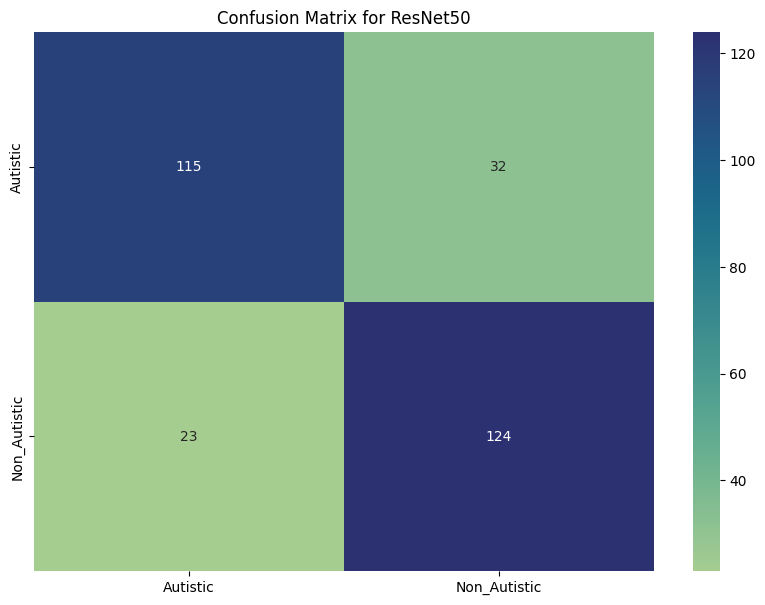

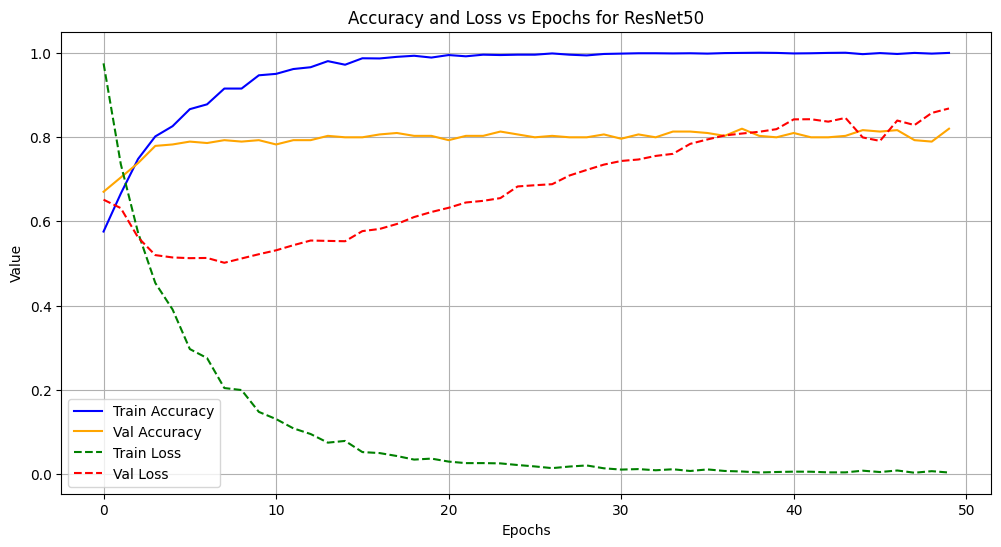

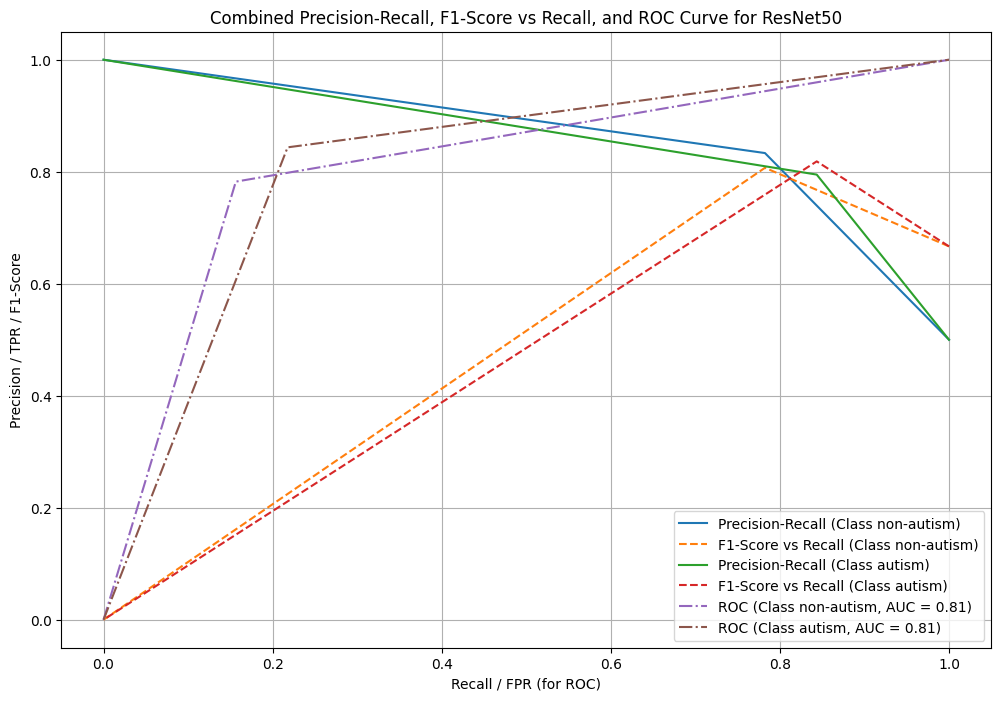

Testing random image: output/test/Non_Autistic/0142.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted class: Non_Autistic
Confidence: 99.96%
Spectrum Severity: Severe


In [ ]:
# Train and evaluate models
model_names = ['ResNet50', ]
for model_name in model_names:
    model = create_model(model_name)
    train_and_evaluate_model(model, train_data, val_data, test_data, model_name)


# Test the model on a random image
for model_name in model_names:
    test_random_image(model, test_dir, class_names)